# Task 5: Exploratory Data Analysis (EDA)
### Dataset: Titanic Passenger Data
**Objective:** Extract insights using visual and statistical exploration.

**Why this dataset?** It has both numeric columns (Age, Fare, SibSp, Parch, Pclass) and
categorical columns (Sex, Embarked, Class), so it lets us practice every EDA technique
required for this task on one clean, well-known dataset.


## Step 1: Import Libraries
We import `pandas` for handling tabular data, `matplotlib` and `seaborn` for plotting.
Seaborn is built on top of matplotlib and makes statistical plots easier to create.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## Step 2: Load the Dataset
We load the Titanic dataset directly from a CSV file into a pandas DataFrame.
A DataFrame is just a table (rows and columns) that pandas can easily analyze.

In [24]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3: Basic Inspection

**Why we do this:** Before analyzing any dataset, we must understand its structure —
how many rows/columns it has, what data types each column is, whether there
are missing values, and what the numeric columns look like statistically.

- `.info()` → shows column names, data types, and non-null counts (helps spot missing data)
- `.describe()` → shows count, mean, std, min, max, and quartiles for numeric columns
- `.value_counts()` → shows the frequency of each category in a categorical column

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [26]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [27]:
print("Survived counts:\n", df['survived'].value_counts())
print("\nSex counts:\n", df['sex'].value_counts())
print("\nPclass counts:\n", df['pclass'].value_counts())
print("\nEmbarked counts:\n", df['embarked'].value_counts())

Survived counts:
 survived
0    549
1    342
Name: count, dtype: int64

Sex counts:
 sex
male      577
female    314
Name: count, dtype: int64

Pclass counts:
 pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked counts:
 embarked
S    644
C    168
Q     77
Name: count, dtype: int64


**Observation:** The dataset has 891 rows and 15 columns. The `age` column has 177
missing values and `deck` has 688 missing values (mostly empty, so we will ignore `deck`
in our numeric analysis). `embarked` has 2 missing values. About 38% of passengers
survived (342 out of 891).

## Step 4: Univariate Analysis — Histograms

**What is Univariate Analysis?** Studying ONE variable at a time — its distribution,
central tendency (mean/median), and spread. Histograms are the standard tool because
they show how values are distributed across ranges (bins).

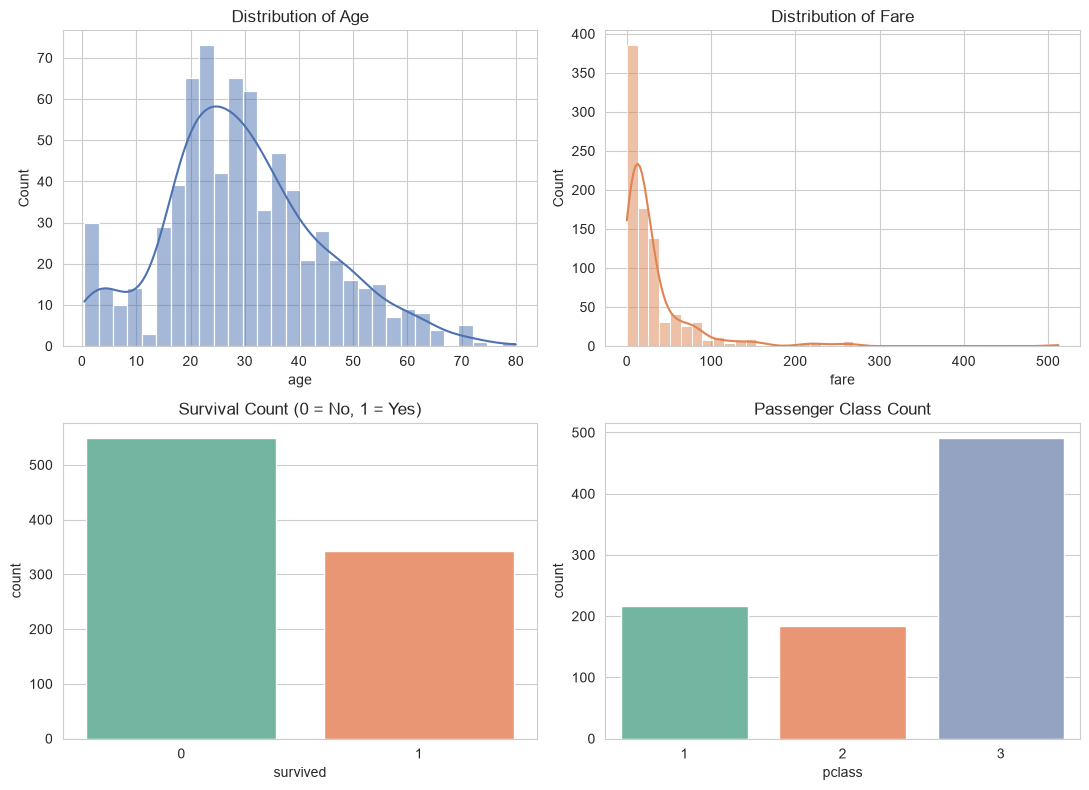

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Distribution of Age')

sns.histplot(df['fare'], bins=40, kde=True, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Distribution of Fare')

sns.countplot(x='survived', data=df, ax=axes[1,0], hue='survived', palette='Set2', legend=False)
axes[1,0].set_title('Survival Count (0 = No, 1 = Yes)')

sns.countplot(x='pclass', data=df, ax=axes[1,1], hue='pclass', palette='Set2', legend=False)
axes[1,1].set_title('Passenger Class Count')

plt.tight_layout()
plt.show()

**Observations:**
- `age` is roughly bell-shaped but slightly right-skewed (skewness ≈ 0.39) — most passengers
  are between 20-40 years old, with a small number of older passengers.
- `fare` is heavily right-skewed (skewness ≈ 4.79) — most tickets were cheap, but a few
  first-class tickets cost a lot, creating a long tail.
- More passengers did not survive (549) than survived (342).
- Passenger class 3 (Third/economy) had the most passengers (491).

## Step 5: Bivariate Analysis — Boxplots & Scatterplots

**What is Bivariate Analysis?** Studying the relationship between TWO variables.
- Boxplots compare a numeric variable across categories (and reveal outliers).
- Scatterplots show how two numeric variables move together.

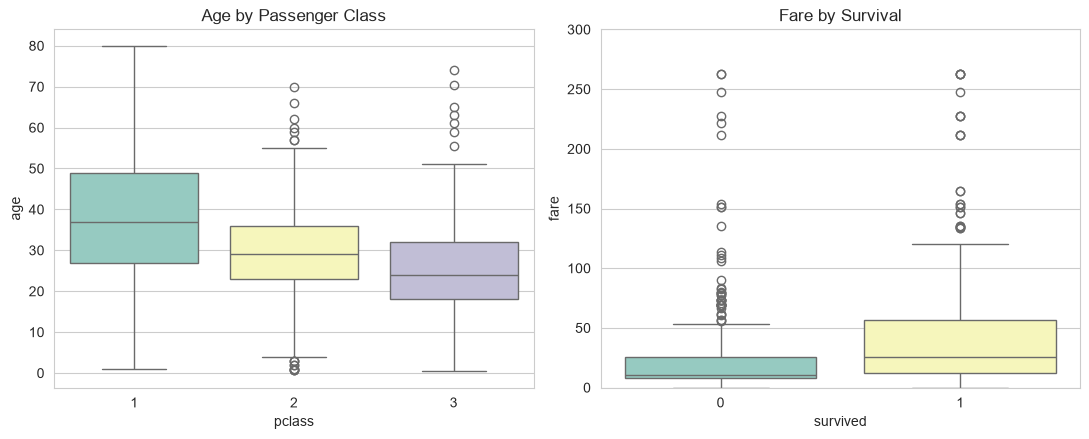

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(x='pclass', y='age', data=df, ax=axes[0], hue='pclass', palette='Set3', legend=False)
axes[0].set_title('Age by Passenger Class')

sns.boxplot(x='survived', y='fare', data=df, ax=axes[1], hue='survived', palette='Set3', legend=False)
axes[1].set_title('Fare by Survival')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

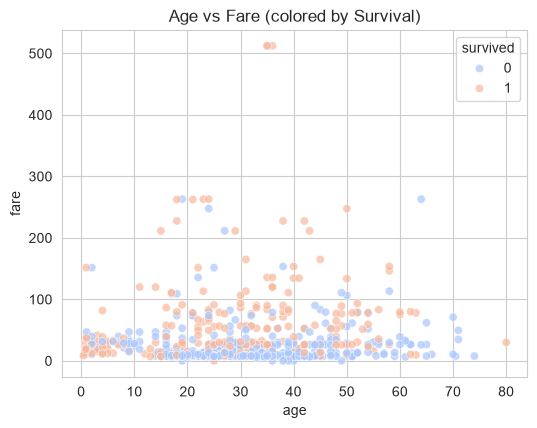

In [30]:
plt.figure(figsize=(6,4.5))
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='coolwarm', alpha=0.7)
plt.title('Age vs Fare (colored by Survival)')
plt.show()

**Observations:**
- First-class (`pclass`=1) passengers tend to be older on average than third-class
  passengers — makes sense, as wealthier/older passengers could afford better tickets.
- Passengers who survived tend to have paid slightly higher fares — fare has some
  outliers reaching over 500.
- The scatterplot shows no strong linear pattern between Age and Fare, but higher-fare
  passengers (upper area) show more blue dots (survived) than orange.

## Step 6: Multivariate Analysis — Pairplot & Heatmap

**What is Multivariate Analysis?** Studying relationships across THREE or more
variables at once.
- `pairplot()` plots every numeric column against every other numeric column, so we can
  spot patterns across many variables at a glance.
- `heatmap()` on a correlation matrix shows the strength of the linear relationship
  between every pair of numeric columns (from -1 to +1).

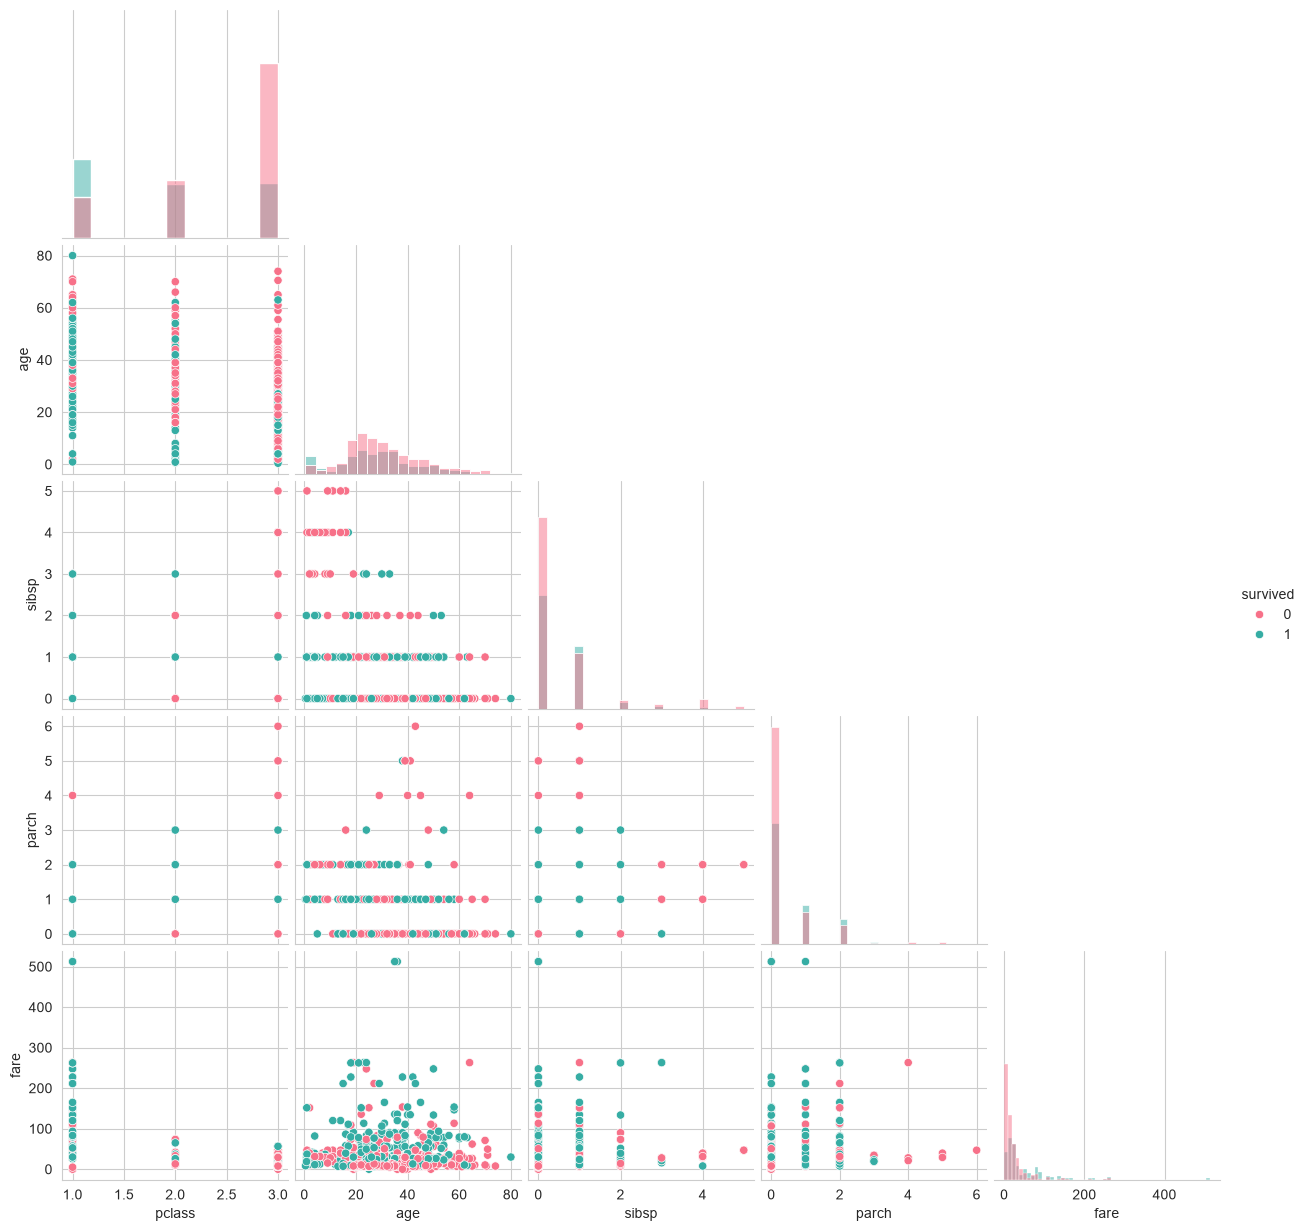

In [31]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
pair_df = df[numeric_cols].dropna()

sns.pairplot(pair_df, hue='survived', palette='husl', corner=True, diag_kind='hist')
plt.show()

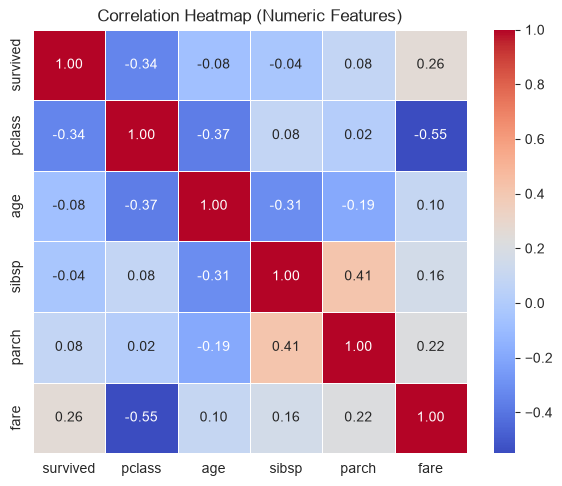

In [32]:
plt.figure(figsize=(7,5.5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

**Observations:**
- `pclass` and `fare` have a fairly strong negative correlation (-0.55) — lower class
  number (better class) is associated with higher fare, which makes sense (Pclass 1 =
  most expensive).
- `survived` correlates most with `fare` (+0.26, positive) and `pclass` (-0.34, negative)
  — passengers who paid more / were in a better class were more likely to survive.
- `sibsp` and `parch` have a moderate positive correlation (0.41) — passengers with more
  siblings/spouses aboard also tended to have more parents/children aboard (larger
  families travelled together).
- No pair of numeric features shows a correlation strong enough (>0.8 or <-0.8) to signal
  serious multicollinearity, so all numeric features could safely be used together in a
  model if needed.

## Step 7: Extra Insight — Survival Rate Breakdown
Beyond the required plots, let's directly compare survival rate by Sex and by Class,
since these looked important in the correlation heatmap.

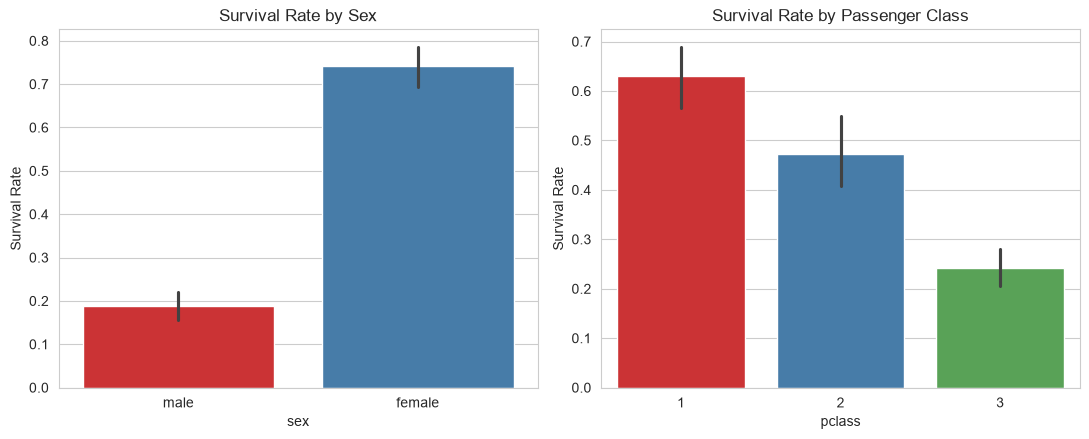

Survival rate by sex:
 sex
female    0.742
male      0.189
Name: survived, dtype: float64

Survival rate by class:
 pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(x='sex', y='survived', data=df, ax=axes[0], hue='sex', palette='Set1', legend=False)
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(x='pclass', y='survived', data=df, ax=axes[1], hue='pclass', palette='Set1', legend=False)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("Survival rate by sex:\n", df.groupby('sex')['survived'].mean().round(3))
print("\nSurvival rate by class:\n", df.groupby('pclass')['survived'].mean().round(3))

**Observations:**
- Women survived at a much higher rate (74.2%) than men (18.9%) — reflects the
  "women and children first" evacuation priority.
- First-class passengers survived at 63%, versus only 24.2% for third-class — better
  access to lifeboats for wealthier passengers likely explains this gap.

## Step 8: Summary of Findings

1. **Survival rate:** Only 38% of passengers survived overall.
2. **Sex was the strongest survival factor:** Women survived far more often (74%) than
   men (19%).
3. **Class mattered a lot:** 1st class passengers survived at 63%, vs 24% in 3rd class —
   likely due to cabin location and lifeboat access.
4. **Fare and Class are closely linked** (correlation -0.55) — 1st class tickets cost
   far more (median ₹60.29) than 3rd class (median ₹8.05).
5. **Fare is heavily right-skewed** — a small number of expensive tickets pull the
   average up; median is a better "typical value" measure than mean for fare.
6. **Age is missing for ~20% of passengers** and **Deck is missing for ~77%** — any
   further modeling should either impute Age (e.g. with median) or drop Deck.
7. **No serious multicollinearity** was found among the numeric features, so all of them
   remain safe to use together for further analysis or modeling.
